In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/emi_nav.db")

# Überblick
print("=== RUNS ===")
print(pd.read_sql("SELECT * FROM runs", conn))

print("\n=== IMU Zeilen pro Run & Sensor ===")
print(pd.read_sql("""
    SELECT run_id, sensor, COUNT(*) as n 
    FROM imu GROUP BY run_id, sensor ORDER BY run_id, sensor
""", conn))

print("\n=== BLE Zeilen pro Run ===")
print(pd.read_sql("""
    SELECT run_id, COUNT(*) as messungen, COUNT(DISTINCT beacon_name) as beacons
    FROM ble_rssi GROUP BY run_id
""", conn))

=== RUNS ===
  run_id                              filename        date notes
0     R1  R1_pickup_export_20260616_141816.csv  2026-06-16      
1     R2  R2_pickup_export_20260616_150505.csv  2026-06-16      
2     R3  R3_pickup_export_20260616_151247.csv  2026-06-16      

=== IMU Zeilen pro Run & Sensor ===
   run_id         sensor      n
0      R1          accel   7575
1      R1           gyro   7575
2      R1  imu_processed  22725
3      R1            mag   7575
4      R2          accel  17366
5      R2           gyro  17367
6      R2  imu_processed  52076
7      R2            mag  17367
8      R3          accel  25629
9      R3           gyro  25629
10     R3  imu_processed  76887
11     R3            mag  25629

=== BLE Zeilen pro Run ===
  run_id  messungen  beacons
0     R1        515        7
1     R2       1469        7
2     R3       1788        7


In [2]:
df = pd.read_sql("""
    SELECT run_id, 
           MIN(timestamp_ms) as start_ms,
           MAX(timestamp_ms) as end_ms,
           ROUND((MAX(timestamp_ms) - MIN(timestamp_ms)) / 1000.0, 1) as dauer_sek
    FROM imu GROUP BY run_id
""", conn)

print("=== Dauer pro Run ===")
print(df)

=== Dauer pro Run ===
  run_id       start_ms         end_ms  dauer_sek
0     R1  1781612173659  1781612234280       60.6
1     R2  1781614911341  1781615050341      139.0
2     R3  1781615346887  1781615552012      205.1


In [3]:
ble = pd.read_sql("SELECT * FROM ble_rssi", conn)

print("=== RSSI Statistik pro Beacon (alle Runs) ===")
print(ble.groupby("beacon_name")["rssi"].agg(["count","mean","min","max"]).round(1).sort_values("count", ascending=False))

=== RSSI Statistik pro Beacon (alle Runs) ===
              count  mean    min    max
beacon_name                            
arrive_emi4     903 -82.4 -102.0  -54.0
arrive_emi3     800 -85.9 -105.0  -63.0
arrive_emi10    721 -86.0 -104.0  -62.0
arrive_emi2     449 -86.1 -102.0  127.0
arrive_emi8     440 -85.5 -102.0  -66.0
arrive_emi1     370 -85.3 -102.0  -66.0
FBADD6D492CE     89 -87.1 -101.0  -66.0


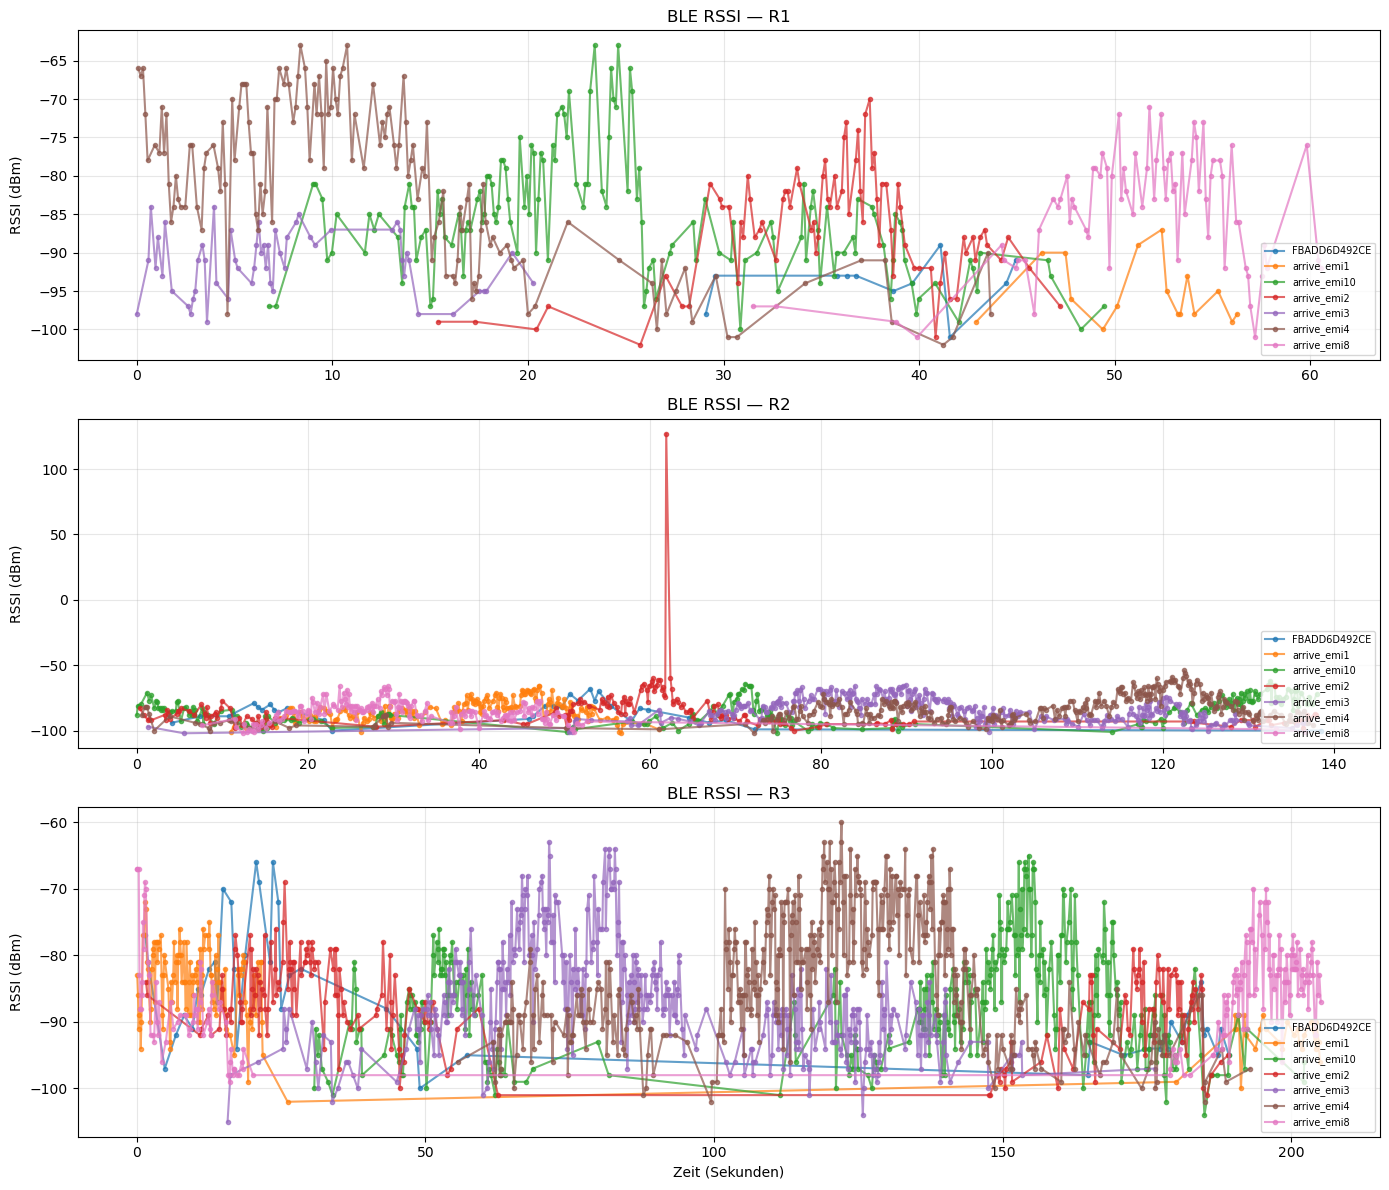

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, run_id in zip(axes, ["R1", "R2", "R3"]):
    ble = pd.read_sql(f"""
        SELECT timestamp_ms, beacon_name, rssi FROM ble_rssi
        WHERE run_id = '{run_id}' ORDER BY timestamp_ms
    """, conn)
    ble["t_sec"] = (ble["timestamp_ms"] - ble["timestamp_ms"].min()) / 1000

    for beacon, grp in ble.groupby("beacon_name"):
        ax.plot(grp["t_sec"], grp["rssi"], marker=".", linestyle="-", alpha=0.7, label=beacon)

    ax.set_title(f"BLE RSSI — {run_id}")
    ax.set_ylabel("RSSI (dBm)")
    ax.legend(loc="lower right", fontsize=7)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Zeit (Sekunden)")
plt.tight_layout()
plt.show()

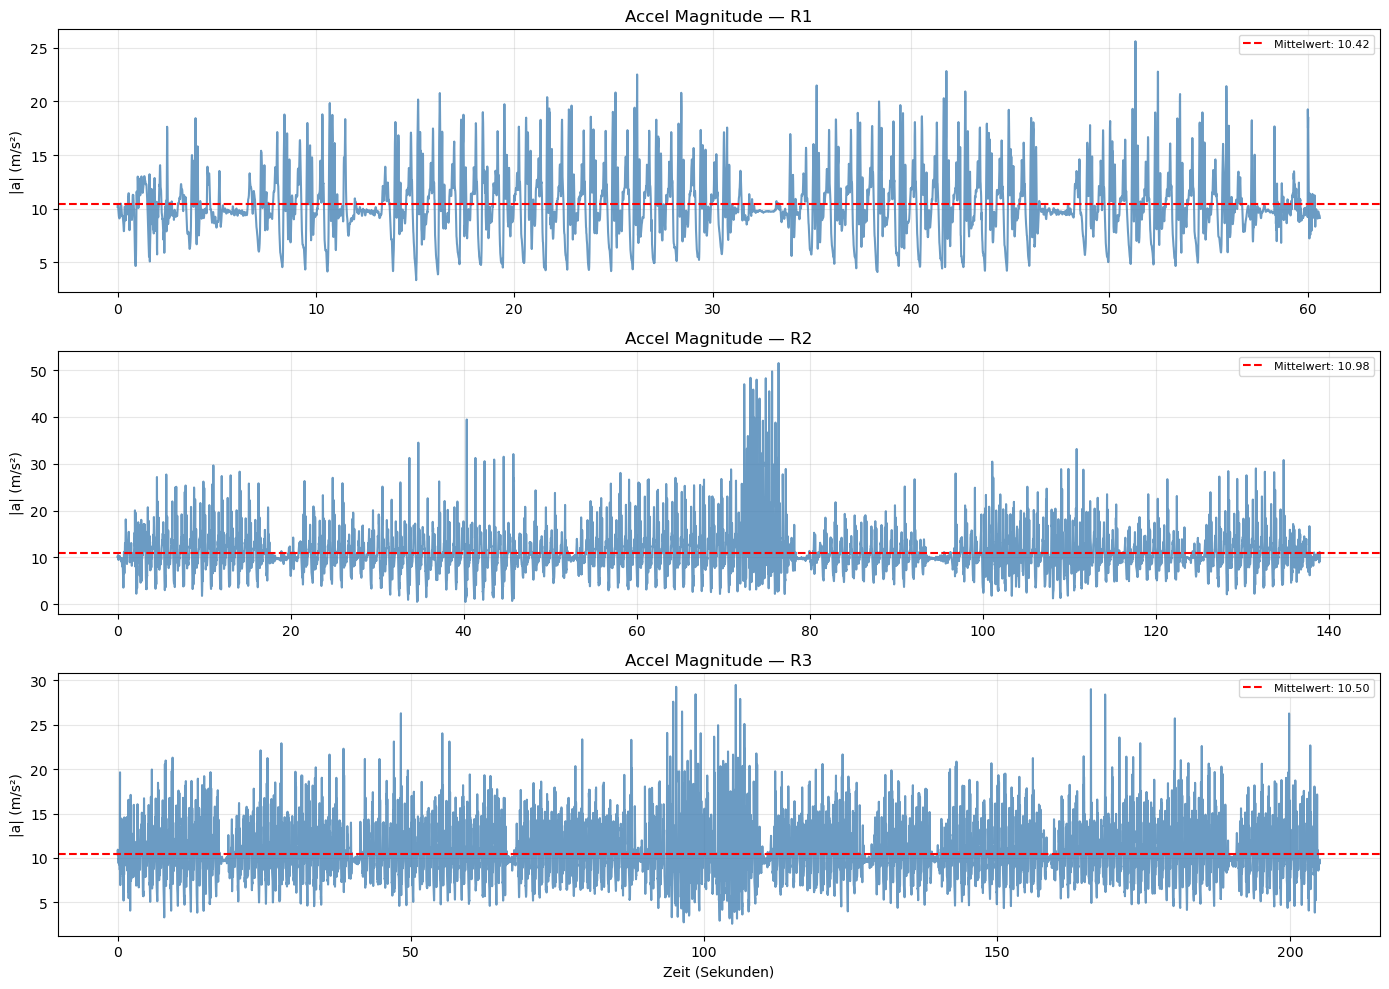

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, run_id in zip(axes, ["R1", "R2", "R3"]):
    accel = pd.read_sql(f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'accel'
        ORDER BY timestamp_ms
    """, conn)
    accel["t_sec"] = (accel["timestamp_ms"] - accel["timestamp_ms"].min()) / 1000
    accel["magnitude"] = (accel["x"]**2 + accel["y"]**2 + accel["z"]**2)**0.5

    ax.plot(accel["t_sec"], accel["magnitude"], color="steelblue", alpha=0.8)
    ax.axhline(y=accel["magnitude"].mean(), color="red", linestyle="--",
               label=f"Mittelwert: {accel['magnitude'].mean():.2f}")
    ax.set_title(f"Accel Magnitude — {run_id}")
    ax.set_ylabel("|a| (m/s²)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Zeit (Sekunden)")
plt.tight_layout()
plt.show()

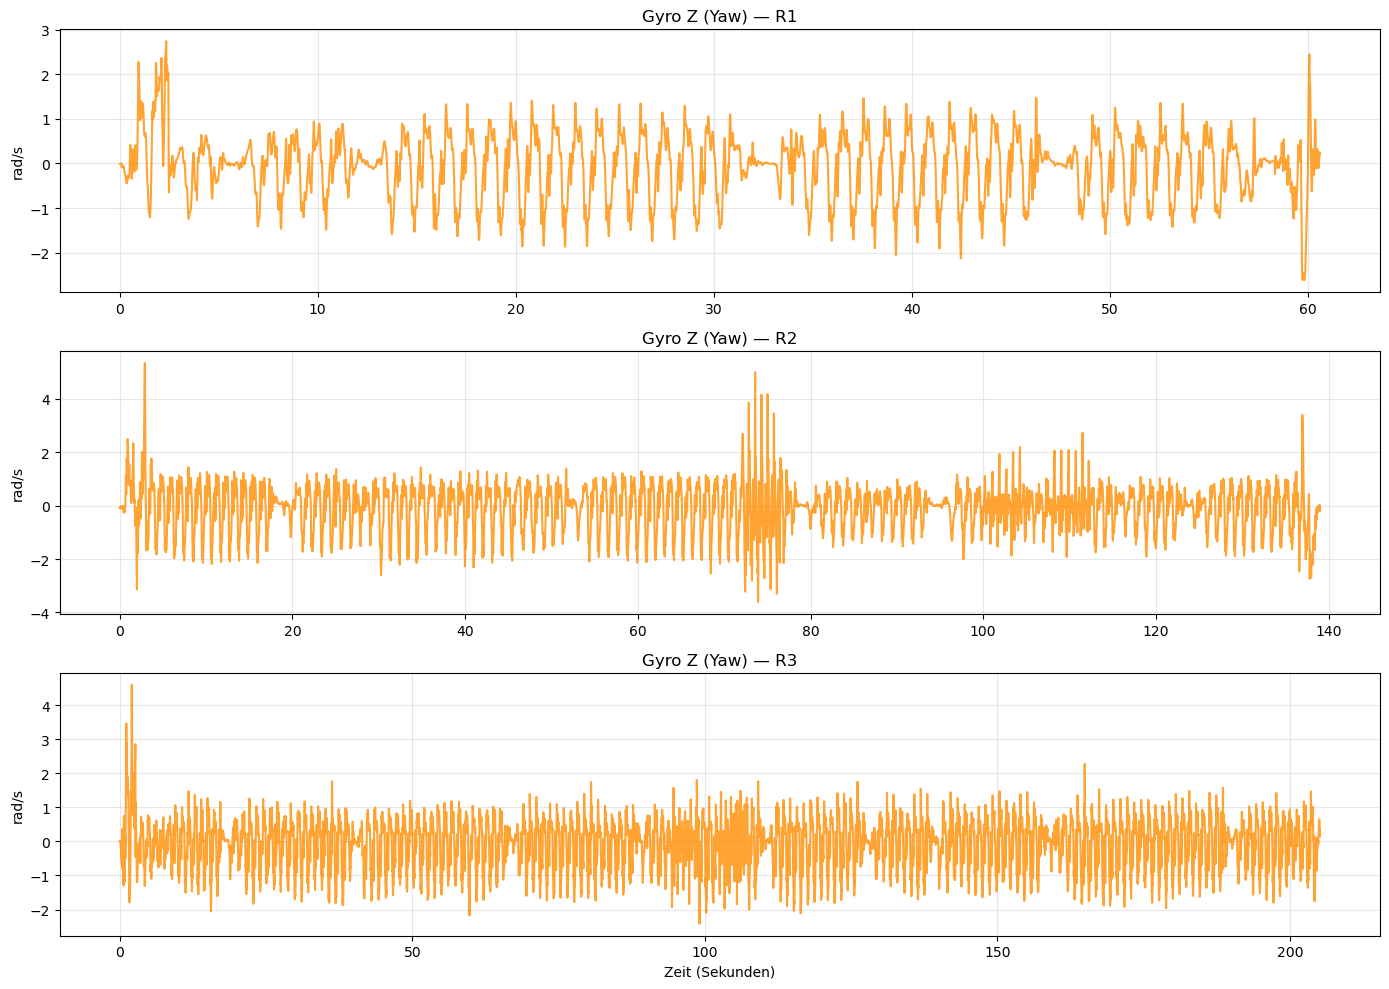

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, run_id in zip(axes, ["R1", "R2", "R3"]):
    gyro = pd.read_sql(f"""
        SELECT timestamp_ms, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'gyro'
        ORDER BY timestamp_ms
    """, conn)
    gyro["t_sec"] = (gyro["timestamp_ms"] - gyro["timestamp_ms"].min()) / 1000

    ax.plot(gyro["t_sec"], gyro["z"], color="darkorange", alpha=0.8)
    ax.set_title(f"Gyro Z (Yaw) — {run_id}")
    ax.set_ylabel("rad/s")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Zeit (Sekunden)")
plt.tight_layout()
plt.show()